In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('dataset/Netflix Content Strategy Genre & Rating Analysis/netflix_titles.csv')

df.fillna('Unknown', inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      8807 non-null   str           
 4   cast          8807 non-null   str           
 5   country       8807 non-null   str           
 6   date_added    8709 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   str           
 9   duration      8807 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 3.8 MB


In [3]:
content_counts = df['type'].value_counts()
print(content_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [4]:
top_genres = df['listed_in'].str.split(', ').explode().value_counts()
top_genres.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [5]:
top_countries = df['country'].str.split(', ').explode().value_counts()
print(top_countries.head(10))

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [6]:
# ۱. همون جدا کردن که قبلاً کردیم (مطمئن شو این قسمت اجرا شده)
df_exploded = df.copy()
df_exploded['genre'] = df['listed_in'].str.split(', ')
df_exploded = df_exploded.explode('genre')

# ۲. به جای crosstab، از groupby استفاده می‌کنیم
# این کد می‌گه: "بگروپ (گروه‌بندی کن) بر اساس کشور و ژانر، بعد تعدادشون رو بشمار"
result = df_exploded.groupby(['country', 'genre']).size().unstack(fill_value=0)

# ۳. حالا انتخاب می‌کنیم (۵ کشور برتر و ۵ ژانر برتر)
# top_countries و top_genres رو قبلاً تعریف کردیم
top_5_countries = top_countries.index[:5]
top_5_genres = top_genres.index[:5]

final_analysis = result.loc[top_5_countries, top_5_genres].sort_values

print("تحلیل ترکیبی کشورها و ژانرها (روش جایگزین):")

final_analysis

تحلیل ترکیبی کشورها و ژانرها (روش جایگزین):


<bound method DataFrame.sort_values of listed_in       International Movies  Dramas  Comedies  \
country                                                  
United States                     21     591       524   
India                            817     620       308   
Unknown                          209     110        94   
United Kingdom                    66      45        32   
Canada                            26      22        39   

listed_in       International TV Shows  Documentaries  
country                                                
United States                       27            411  
India                               65             19  
Unknown                            223             75  
United Kingdom                     112             84  
Canada                              19             21  >

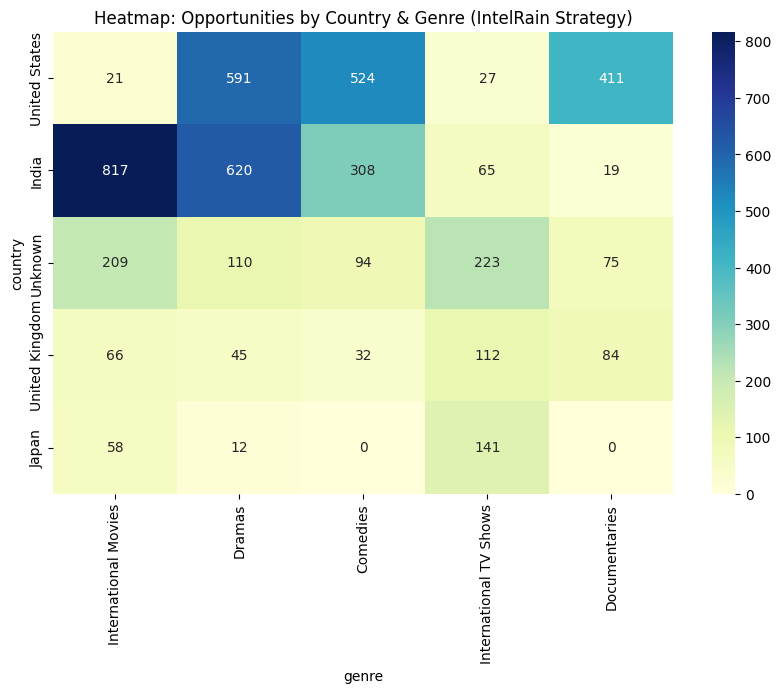

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# ۱. بازسازی دیتافریم (مطمئن می‌شیم که دیتا درسته)
# فرض می‌کنم df_exploded همون چیزیه که قبلاً درست کردیم
df_subset = df_exploded.groupby(['country', 'genre']).size().unstack(fill_value=0)

# انتخاب ۵ کشور و ۵ ژانر برتر (برای اینکه شلوغ نشه)
top_5_countries = df_subset.sum(axis=1).nlargest(5).index
top_5_genres = df_subset.sum(axis=0).nlargest(5).index
data_to_plot = df_subset.loc[top_5_countries, top_5_genres]

# ۲. رسم نقشه حرارتی
plt.figure(figsize=(10, 6))
sns.heatmap(data_to_plot, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap: Opportunities by Country & Genre (IntelRain Strategy)')
plt.show()


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


In [9]:
df["description"] = df['description'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['description'])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


indices = pd.Series(df.index, index=df['title']).drop_duplicates()


def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in indices:
        return "Title not found in the Netflix dataset."
    
    idx = indices[title]
        
    sim_scores = list(enumerate(cosine_sim[idx]))

    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    sim_scores = sim_scores[1:11]
    
    movie_indices = [i[0] for i in sim_scores]

    return df['title'].iloc[movie_indices]


print("'Stranger Things':")
print(get_recommendations('Stranger Things'))



'Stranger Things':
4733               Rowdy Rathore
1240                  Safe Haven
1487             Sakho & Mangane
8198     The Autopsy of Jane Doe
2419               Big Stone Gap
6518            Come and Find Me
6760                   FirstBorn
8026             Sinister Circle
4201                 Hardy Bucks
1270    Sin senos sí hay paraíso
Name: title, dtype: str


In [10]:
features = ['description', 'listed_in', 'director', 'cast']
for feature in features:
    df[feature] = df[feature].fillna('')

def create_soup(x):
    return x['description'] + ' ' + x['listed_in'] + ' ' + x['director'] + ' ' + x['cast']

df['combined_features'] = df.apply(create_soup, axis=1)


tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined_features'])

cosine_sim_advanced = cosine_similarity(tfidf_matrix, tfidf_matrix)

def get_advanced_recommendations(title, cosine_sim=cosine_sim_advanced):
    if title not in indices:
        return "Title not found in the Netflix dataset."
    
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]

print(get_advanced_recommendations('Stranger Things'))


5200         Beyond Stranger Things
1127               Prank Encounters
2190           The Umbrella Academy
6167    Anjaan: Special Crimes Unit
3398                            Eli
4809                  Kiss Me First
1240                     Safe Haven
1396                      Homefront
2600                     Good Witch
880                         Haunted
Name: title, dtype: str
